In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.optimize import curve_fit
import sympy
from sympy import symbols, diff
from visualizations import lineplots_4x4, smooth_func
from processing import filter_region
from datetime import datetime
import glasbey

# load prediction arrays, create array objects

In [4]:
folder_path = 'predictions/8-27-2025/'

In [5]:
folders = [folder for folder in os.listdir(folder_path)]
print('len of folders: ', len(folders))

len of folders:  110


In [6]:
test_sum = np.load(f'{folder_path}image0/sum_arr_image0.npy')
print('test_sum shape: ', test_sum.shape)

test_sum shape:  (1, 100, 7493)


In [7]:
def load_arrs(arr_type: str):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [8]:
sum_arr = load_arrs('sum')
mean_arr = load_arrs('mean')
var_arr = load_arrs('var')
label_arr = load_arrs('label')

In [9]:
print(f'sum shape: {sum_arr.shape}; mean shape: {mean_arr.shape}; var shape: {var_arr.shape}')

sum shape: (110, 100, 7493); mean shape: (110, 7493); var shape: (110, 7493)


In [10]:
np.unique(mean_arr == var_arr, return_counts = True) # ensure we are returning different arrays

(array([False]), array([824230]))

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [11]:
mean_v1 = filter_region(1, label_arr, mean_arr)
var_v1 = filter_region(1, label_arr, var_arr)

In [12]:
print(f'mean shape: {mean_v1.shape}, var shape: {var_v1.shape}')

mean shape: (110, 5312), var shape: (110, 5312)


### remove anything above 200 spikes/sec

In [13]:
mean_v1_removed = remove_rate(mean_v1, 200)

NameError: name 'remove_rate' is not defined

In [ ]:
print('mean shape:', mean_v1_removed.shape)

In [ ]:
np.unique(np.isnan(mean_v1_removed), return_counts = True)

In [ ]:
var_v1_removed = np.where(np.isnan(mean_v1_removed), mean_v1_removed, var_v1)

In [ ]:
print('var shape:', var_v1_removed.shape)

In [ ]:
np.unique(np.isnan(var_v1_removed), return_counts = True)

In [ ]:
test_neuron = 250

In [ ]:
mean_v1_removed[..., test_neuron]

In [ ]:
var_v1_removed[..., test_neuron]

### get indices to sort

In [ ]:
print(f'unique counts for mean_arr:', np.unique(np.isnan(mean_v1_removed), return_counts = True))
print(f'unique counts for var_arr:', np.unique(np.isnan(var_v1_removed), return_counts = True))
print('ensure that we have the same counts for both arrays')

In [ ]:
# run this when wanting to use array with removed values
med_arr = np.nanmedian(mean_v1_removed, axis = 0)
med_arr.shape

In [14]:
# run this when wanting to use array WITHOUT removed values
med_arr = np.nanmedian(mean_v1, axis = 0)
med_arr.shape

(5312,)

In [ ]:
for med_num in med_arr: print(med_num)

In [15]:
sort_indices = np.argsort(med_arr)[::-1]

In [16]:
len(sort_indices)

5312

In [ ]:
# use this for when we remove above x rate
mean_v1_sorted = mean_v1_removed[..., sort_indices]
var_v1_sorted = var_v1_removed[..., sort_indices]

In [17]:
# use this OTHERWISE
mean_v1_sorted = mean_v1[..., sort_indices]
var_v1_sorted = var_v1[..., sort_indices]

In [ ]:
for neuron in range(mean_v1_sorted.shape[1]):
    print(np.nanmedian(mean_v1_sorted[..., neuron]))

#### *note that this code works and has been checked properly up to here*

In [ ]:
mean_v1_sorted[...,110]

In [ ]:
var_v1_sorted[..., 110]

In [ ]:
lineplots_4x4('test', mean_v1_sorted, var_v1_sorted)

In [ ]:
neuron = 0
mean_masked = mean_v1_sorted
var_masked = var_v1_sorted

mask = ~np.isnan(mean_masked[..., neuron]) & ~np.isnan(var_masked[..., neuron])

x_nonan = mean_masked[..., neuron][mask]
y_nonan = var_masked[..., neuron][mask]

params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1,0.001])
x_max = np.max(x_nonan)

y_pred = smooth_func(np.linspace(0, x_max, 1000), params[0], params[1])
plt.plot(np.linspace(0, x_max, 1000), y_pred, color='r', label='smooth function regression', alpha=0.7)
#plt.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left')

plt.scatter(x_nonan, y_nonan)
plt.show()

# adjusting scatter plot

In [ ]:
# per ralf's comments, play around with scaling

def lineplots_4x4(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], savefig = False):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron]) & ~np.isnan(var_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, 0.001])
        x_min, x_max = ax.get_xlim()
        y_pred = smooth_func(np.linspace(0, x_max, 1000), params[0], params[1])
        ax.plot(np.linspace(0, x_max, 1000), y_pred, color='r', label='smooth function regression', alpha=0.7)
        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        #ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers
        
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

In [ ]:
lineplots_4x4('Sorted by Highest Median Descending\nNeurons 48-64', mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(48, 64)])

# plot in log space

In [ ]:
def lineplots_4x4(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], savefig = False):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan), 100), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        #ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers

        ax.set_xscale('log')
        ax.set_yscale('log')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

# final function (september 29th)

In [ ]:
def lineplots_4x4(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], savefig = False, logspace = False):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan), 100), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        #ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers

        if logspace: 
            ax.set_xscale('log')
            ax.set_yscale('log')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

In [ ]:
lineplots_4x4('Sorted by Highest Median Descending\nNeurons 1-16 (log space)', mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(16)], logspace = True )

# a*x^b

In [ ]:
def smooth_func(x, a, b): # used for regression in lineplots_4x4

    return a * x ** b

In [ ]:
def lineplots_4x4(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], savefig = False, logspace = False):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan), 100), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        #ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers

        if logspace: 
            ax.set_xscale('log')
            ax.set_yscale('log')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

In [ ]:
lineplots_4x4('Sorted by Highest Median Descending\nNeurons 1-16 (a*x^b)', mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(16)], logspace = False )

In [ ]:
lineplots_4x4('Sorted by Highest Median Descending\nNeurons 1-16 (log space, a*x^b)', mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(16)], logspace = True )

# slope at x=100 vs median 

In [ ]:
x, m, b = symbols('x m b')

In [ ]:
func_expr = (m / b) * (sympy.log(1 + sympy.exp(b * x)) - sympy.log(2) - (b * x) / 2)

In [ ]:
func_prime = diff(func_expr, x)

In [ ]:
answer = func_prime.subs({x: 50, m: 1, b: .001})
answer

In [ ]:
m, b = np.polyfit(x_data, y_data, 1)

# Create the scatter plot
plt.scatter(x_data, y_data, label='Data Points')

# Plot the regression line
# The equation for a straight line is y = m*x + b
plt.plot(x_data, m * x_data + b, color='red', label='Regression Line')

In [41]:
def slope_median(main_title, mean_masked, var_masked, savefig = False, logspace = False, x_val = 100):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    medians = []
    slopes = []
    # define function
    x, m, b = symbols('x m b')
    func_expr = (m / b) * (sympy.log(1 + sympy.exp(b * x)) - sympy.log(2) - (b * x) / 2) # change function?
    func_prime = diff(func_expr, x)

    for neuron in range(mean_masked.shape[1]):
        
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])

        # calculate slope at specified x_value
        slope = func_prime.subs({x: x_val, m: params[0], b: params[1]})

        medians.append(np.median(x_nonan))
        slopes.append(slope)
    medians, slopes = medians.astype(int), slopes.astype(int)
    plt.scatter(medians, slopes, alpha = 0.1)
    # regression
    m, b = np.polyfit(medians, slopes, 1)
    plt.plot(medians, m * medians + b, color='red', label='Regression Line')
    
    plt.title(f'{main_title}')
    plt.xlabel('median')
    plt.ylabel('slope')
    if logspace: 
        plt.xscale('log')
        plt.yscale('log')
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

In [42]:
slope_median('Slope for Original Smooth Function Against Median Value', mean_v1_sorted, var_v1_sorted, logspace = False)

c:\Users\joshf\OneDrive\GitHub\fnn-haefner\visualizations.py:780: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)


AttributeError: 'list' object has no attribute 'astype'

In [ ]:
def slope_median(main_title, mean_masked, var_masked, savefig = False, logspace = False, x_val = 100):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    medians = []
    slopes = []
    # define function
    x, m, b = symbols('x m b')
    func_expr = (m / b) * (sympy.log(1 + sympy.exp(b * x)) - sympy.log(2) - (b * x) / 2) # change function?
    func_prime = diff(func_expr, x)

    for neuron in range(mean_masked.shape[1]):
        
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])

        # calculate slope at specified x_value
        slope = func_prime.subs({x: x_val, m: params[0], b: params[1]})

        medians.append(np.median(x_nonan))
        slopes.append(slope)
    
    plt.scatter(medians, slopes, alpha = 0.1, marker = '.')
    plt.title(f'{main_title}')
    plt.xlabel('median')
    plt.ylabel('slope')
    #plt.ylim(0, 25)
    #plt.xlim(0, 3)
    if logspace: 
        plt.xscale('log')
        plt.yscale('log')
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

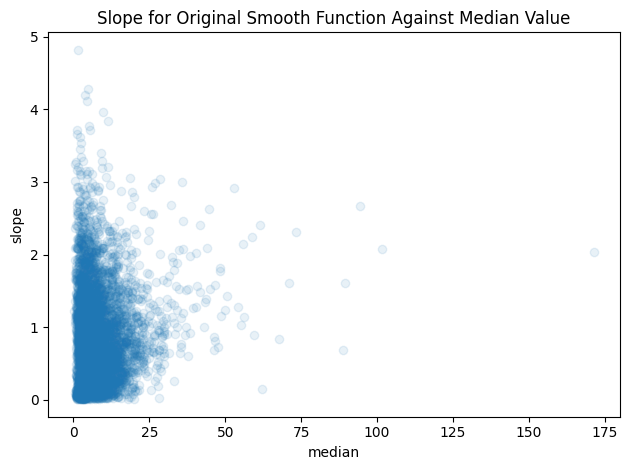

In [44]:
slope_median('Slope for Original Smooth Function Against Median Value', mean_v1_sorted, var_v1_sorted, logspace = False)

In [46]:
x_val = 100

In [45]:
# define function
x, m, b = symbols('x m b')
func_expr = (m / b) * (sympy.log(1 + sympy.exp(b * x)) - sympy.log(2) - (b * x) / 2) # change function?
func_prime = diff(func_expr, x)

In [49]:
medians = []
slopes = []
for neuron in range(mean_v1_sorted.shape[1]):
        
        mask = ~np.isnan(mean_v1_sorted[..., neuron])
        x_nonan = mean_v1_sorted[..., neuron][mask]
        y_nonan = var_v1_sorted[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])

        # calculate slope at specified x_value
        slope = func_prime.subs({x: x_val, m: params[0], b: params[1]})

        medians.append(np.median(x_nonan))
        slopes.append(slope)

c:\Users\joshf\OneDrive\GitHub\fnn-haefner\visualizations.py:780: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)


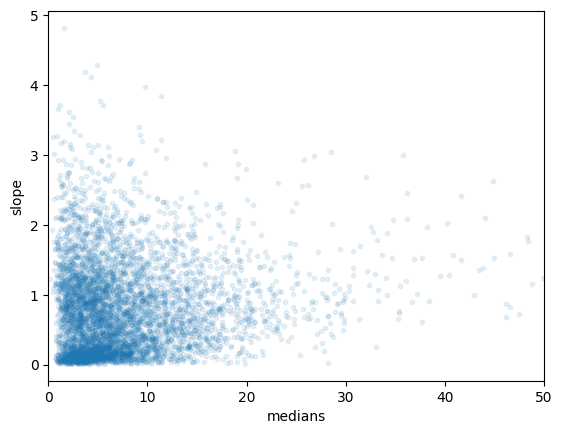

In [51]:
plt.scatter(medians, slopes, marker = '.', alpha = 0.1)
plt.xlim(0, 50)
plt.xlabel('medians')
plt.ylabel('slope')
plt.show()